# Battery Attachment Rate Analysis (Ohm Analytics)

Analyzes three Ohm Analytics exports in `data/Ohm Analytics - Battery Attachment Rates/`:

- **Storage Attachment Rate** — monthly reported attachment rate (%) by state, Jan-19 through May-26
- **Top Solar States** — quarterly + annual solar install counts by state (actual `(A)` vs projected `(P)`)
- **Top Storage States** — same structure, for storage installs

Goals:
1. Tidy all three into long format
2. Cross-check Ohm's reported attachment rate against a derived rate (storage installs / solar installs)
3. Plot trends by state
4. Compare the most recent quarter to dGen's existing input (`dgen_os/input_data/ohm_attachment_rates.csv`)

In [57]:
import os
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = os.path.abspath(os.path.join(os.path.abspath("."), "..", "..", "..", "data", "Ohm Analytics - Battery Attachment Rates"))
DGEN_INPUT_DIR = os.path.abspath(os.path.join(os.path.abspath("."), "..", "..", "input_data"))

ATTACH_FILE = os.path.join(DATA_DIR, "Ohm Analytics Storage Attachment Rate On 2026-7-23.csv")
SOLAR_FILE  = os.path.join(DATA_DIR, "Ohm Analytics Top Solar States On 2026-7-23.csv")
STORAGE_FILE = os.path.join(DATA_DIR, "Ohm Analytics Top Storage States On 2026-7-23.csv")

print("DATA_DIR:", DATA_DIR)
assert os.path.exists(ATTACH_FILE), ATTACH_FILE
assert os.path.exists(SOLAR_FILE), SOLAR_FILE
assert os.path.exists(STORAGE_FILE), STORAGE_FILE

DATA_DIR: /Users/wael/Documents/repos/dgen/data/Ohm Analytics - Battery Attachment Rates


## 1) Load & tidy: monthly storage attachment rate

The first column (`AddressStateId`) in the raw file is corrupted (contains percent strings, not IDs) — dropped rather than trusted.

In [58]:
attach_raw = pd.read_csv(ATTACH_FILE)

# Drop the corrupted first column; keep State + month columns
month_cols = [c for c in attach_raw.columns if c not in ("AddressStateId", "State")]
attach_raw = attach_raw[["State"] + month_cols].copy()

# Parse "12.34%" strings -> float fraction (0.1234)
def pct_to_float(s):
    if pd.isna(s):
        return np.nan
    return float(str(s).replace("%", "").replace("'", "")) / 100.0

for c in month_cols:
    attach_raw[c] = attach_raw[c].map(pct_to_float)

attach_long = attach_raw.melt(id_vars="State", value_vars=month_cols,
                               var_name="month_str", value_name="reported_attachment_rate")
attach_long["period"] = pd.PeriodIndex(pd.to_datetime(attach_long["month_str"], format="%b-%y"), freq="M")
attach_long = attach_long.drop(columns="month_str").sort_values(["State", "period"]).reset_index(drop=True)

print(attach_long.shape)
attach_long.head()

(4272, 3)


,State,reported_attachment_rate,period
0,Alabama,0.0,2019-01
1,Alabama,0.0,2019-02
2,Alabama,0.0,2019-03
3,Alabama,0.0,2019-04
4,Alabama,0.0,2019-05


## 2) Load & tidy: quarterly solar and storage install counts

Keeps only the `Q{n}_{yy} (A|P)` columns (drops the annual-total and growth-rate columns), and tags each quarter as Actual vs Projected.

In [59]:
QTR_RE = re.compile(r"^Q([1-4])_(\d{2}) \((A|P)\)$")

def tidy_quarterly_counts(path, value_name):
    df = pd.read_csv(path)
    qtr_cols = [c for c in df.columns if QTR_RE.match(c)]
    long = df[["State"] + qtr_cols].melt(id_vars="State", value_vars=qtr_cols,
                                          var_name="qtr_str", value_name=value_name)
    parsed = long["qtr_str"].str.extract(QTR_RE)
    long["quarter"] = parsed[0].astype(int)
    long["year"] = 2000 + parsed[1].astype(int)
    long["actual_or_projected"] = parsed[2]
    long["period"] = pd.PeriodIndex.from_fields(year=long["year"], quarter=long["quarter"], freq="Q")
    long[value_name] = pd.to_numeric(long[value_name], errors="coerce")
    return long.drop(columns=["qtr_str", "quarter", "year"]).sort_values(["State", "period"]).reset_index(drop=True)

solar_long = tidy_quarterly_counts(SOLAR_FILE, "solar_installs")
storage_long = tidy_quarterly_counts(STORAGE_FILE, "storage_installs")

print("solar_long:", solar_long.shape, " storage_long:", storage_long.shape)
solar_long.head()

solar_long: (1696, 4)  storage_long: (1696, 4)


,State,solar_installs,actual_or_projected,period
0,Alabama,19.0,A,2019Q1
1,Alabama,65.0,A,2019Q2
2,Alabama,59.0,A,2019Q3
3,Alabama,99.0,A,2019Q4
4,Alabama,101.0,A,2020Q1


## 3) Derived attachment rate = storage installs / solar installs

Cross-check against Ohm's own reported (monthly, resampled to quarterly) rate.

In [60]:
counts = pd.merge(
    solar_long, storage_long,
    on=["State", "period", "actual_or_projected"], how="inner"
)
counts["derived_attachment_rate"] = counts["storage_installs"] / counts["solar_installs"]

# Resample Ohm's monthly reported rate to quarterly (mean) for comparison
attach_q = (
    attach_long.assign(period=attach_long["period"].dt.asfreq("Q"))
    .groupby(["State", "period"], as_index=False)["reported_attachment_rate"].mean()
)

compare = pd.merge(counts, attach_q, on=["State", "period"], how="left")
compare["rate_diff"] = compare["derived_attachment_rate"] - compare["reported_attachment_rate"]

print(compare.shape)
compare[["State", "period", "actual_or_projected", "solar_installs", "storage_installs",
         "derived_attachment_rate", "reported_attachment_rate", "rate_diff"]].head(10)

(1696, 8)


,State,period,actual_or_projected,solar_installs,storage_installs,derived_attachment_rate,reported_attachment_rate,rate_diff
0,Alabama,2019Q1,A,19.0,0.0,0.0,0.000000,0.000000
1,Alabama,2019Q2,A,65.0,0.0,0.0,0.000000,0.000000
2,Alabama,2019Q3,A,59.0,0.0,0.0,0.000000,0.000000
3,Alabama,2019Q4,A,99.0,0.0,0.0,0.000000,0.000000
4,Alabama,2020Q1,A,101.0,0.0,0.0,0.000000,0.000000
5,Alabama,2020Q2,A,87.0,0.0,0.0,0.000000,0.000000
6,Alabama,2020Q3,A,89.0,0.0,0.0,0.000000,0.000000
7,Alabama,2020Q4,A,139.0,0.0,0.0,0.000000,0.000000
8,Alabama,2021Q1,A,127.0,0.0,0.0,0.011100,-0.011100
9,Alabama,2021Q2,A,116.0,0.0,0.0,0.010767,-0.010767


In [61]:
# NOTE: the monthly attachment-rate file has no "National" row (state-level only),
# so reported_attachment_rate is NaN for State == "National" in `compare`.
# Build a solar-weighted national reported rate from state-level data instead.
state_level = compare[compare["State"] != "National"].copy()
national_reported = (
    state_level.groupby(["period", "actual_or_projected"])
    .apply(lambda g: np.average(g["reported_attachment_rate"].fillna(0), weights=g["solar_installs"].clip(lower=0)))
    .rename("national_weighted_reported_rate")
    .reset_index()
)

nat = compare[(compare["State"] == "National") & (compare["actual_or_projected"] == "A")].tail(12)
nat = nat.merge(national_reported, on=["period", "actual_or_projected"], how="left")
nat[["period", "solar_installs", "storage_installs", "derived_attachment_rate", "national_weighted_reported_rate"]]

,period,solar_installs,storage_installs,derived_attachment_rate,national_weighted_reported_rate
0,2023Q2,213667.0,21914.0,0.102561,0.095487
1,2023Q3,234365.0,32863.0,0.140221,0.133183
2,2023Q4,204555.0,37779.0,0.184689,0.177373
3,2024Q1,173604.0,38520.0,0.221884,0.222673
4,2024Q2,159525.0,41804.0,0.262053,0.258358
5,2024Q3,168775.0,50381.0,0.298510,0.293701
6,2024Q4,172997.0,54656.0,0.315936,0.340326
7,2025Q1,136162.0,55510.0,0.407676,0.395976
8,2025Q2,139137.0,60403.0,0.434126,0.427158
9,2025Q3,150162.0,68661.0,0.457246,0.445448


## 4) Plot attachment rate trends by state

Top states (by solar installs, 2026Q1 ): ['California', 'Puerto Rico', 'Florida', 'New Jersey', 'Illinois', 'Texas', 'New York', 'Massachusetts', 'Arizona', 'Pennsylvania', 'Connecticut', 'Maryland']


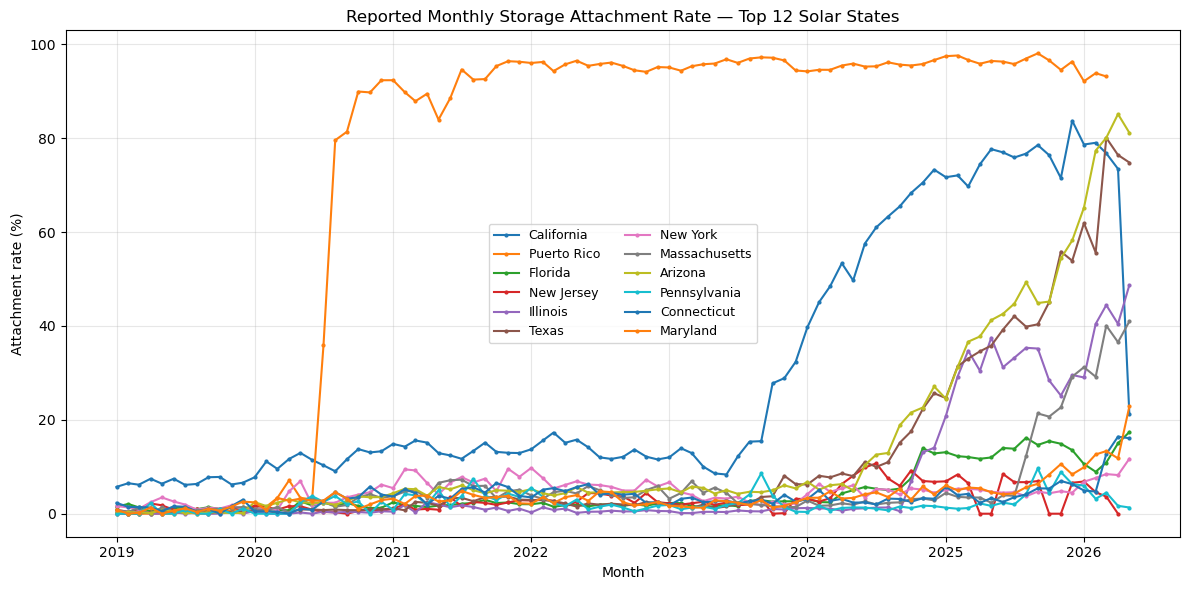

In [62]:
# Top N states by most recent actual-quarter solar volume (excluding National)
latest_actual_q = counts.loc[counts["actual_or_projected"] == "A", "period"].max()
top_states = (
    counts[(counts["period"] == latest_actual_q) & (counts["State"] != "National")]
    .sort_values("solar_installs", ascending=False)
    .head(12)["State"].tolist()
)
print("Top states (by solar installs,", latest_actual_q, "):", top_states)

fig, ax = plt.subplots(figsize=(12, 6))
for state in top_states:
    sub = attach_long[attach_long["State"] == state].sort_values("period")
    ax.plot(sub["period"].dt.to_timestamp(), sub["reported_attachment_rate"] * 100, marker="o", markersize=2, label=state)

ax.set_title("Reported Monthly Storage Attachment Rate — Top 12 Solar States")
ax.set_xlabel("Month")
ax.set_ylabel("Attachment rate (%)")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

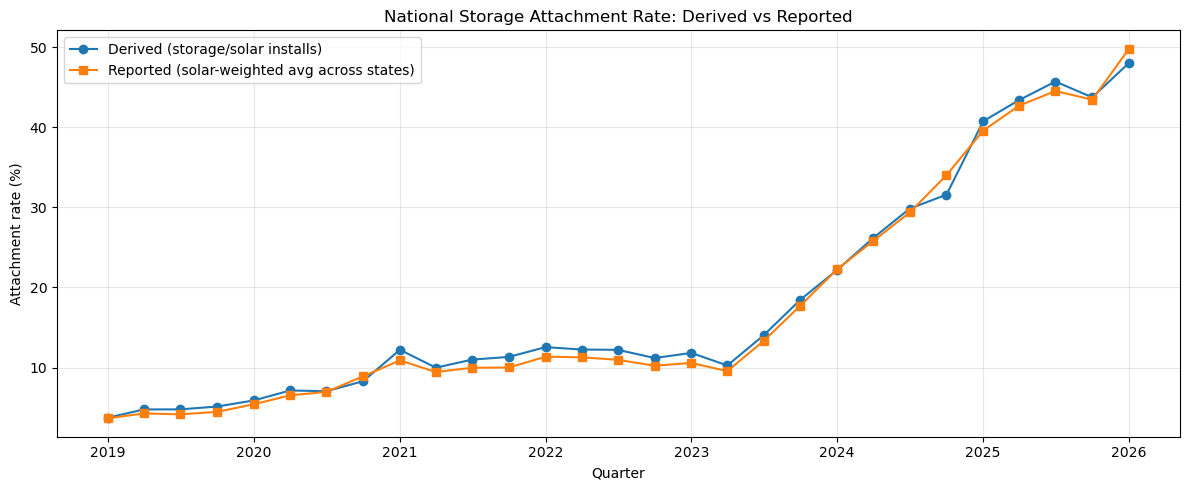

In [63]:
# National: derived vs solar-weighted-reported attachment rate over time (actual quarters only)
nat_actual = compare[(compare["State"] == "National") & (compare["actual_or_projected"] == "A")].sort_values("period")
nat_actual = nat_actual.merge(national_reported, on=["period", "actual_or_projected"], how="left")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(nat_actual["period"].dt.to_timestamp(), nat_actual["derived_attachment_rate"] * 100, marker="o", label="Derived (storage/solar installs)")
ax.plot(nat_actual["period"].dt.to_timestamp(), nat_actual["national_weighted_reported_rate"] * 100, marker="s", label="Reported (solar-weighted avg across states)")
ax.set_title("National Storage Attachment Rate: Derived vs Reported")
ax.set_xlabel("Quarter")
ax.set_ylabel("Attachment rate (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

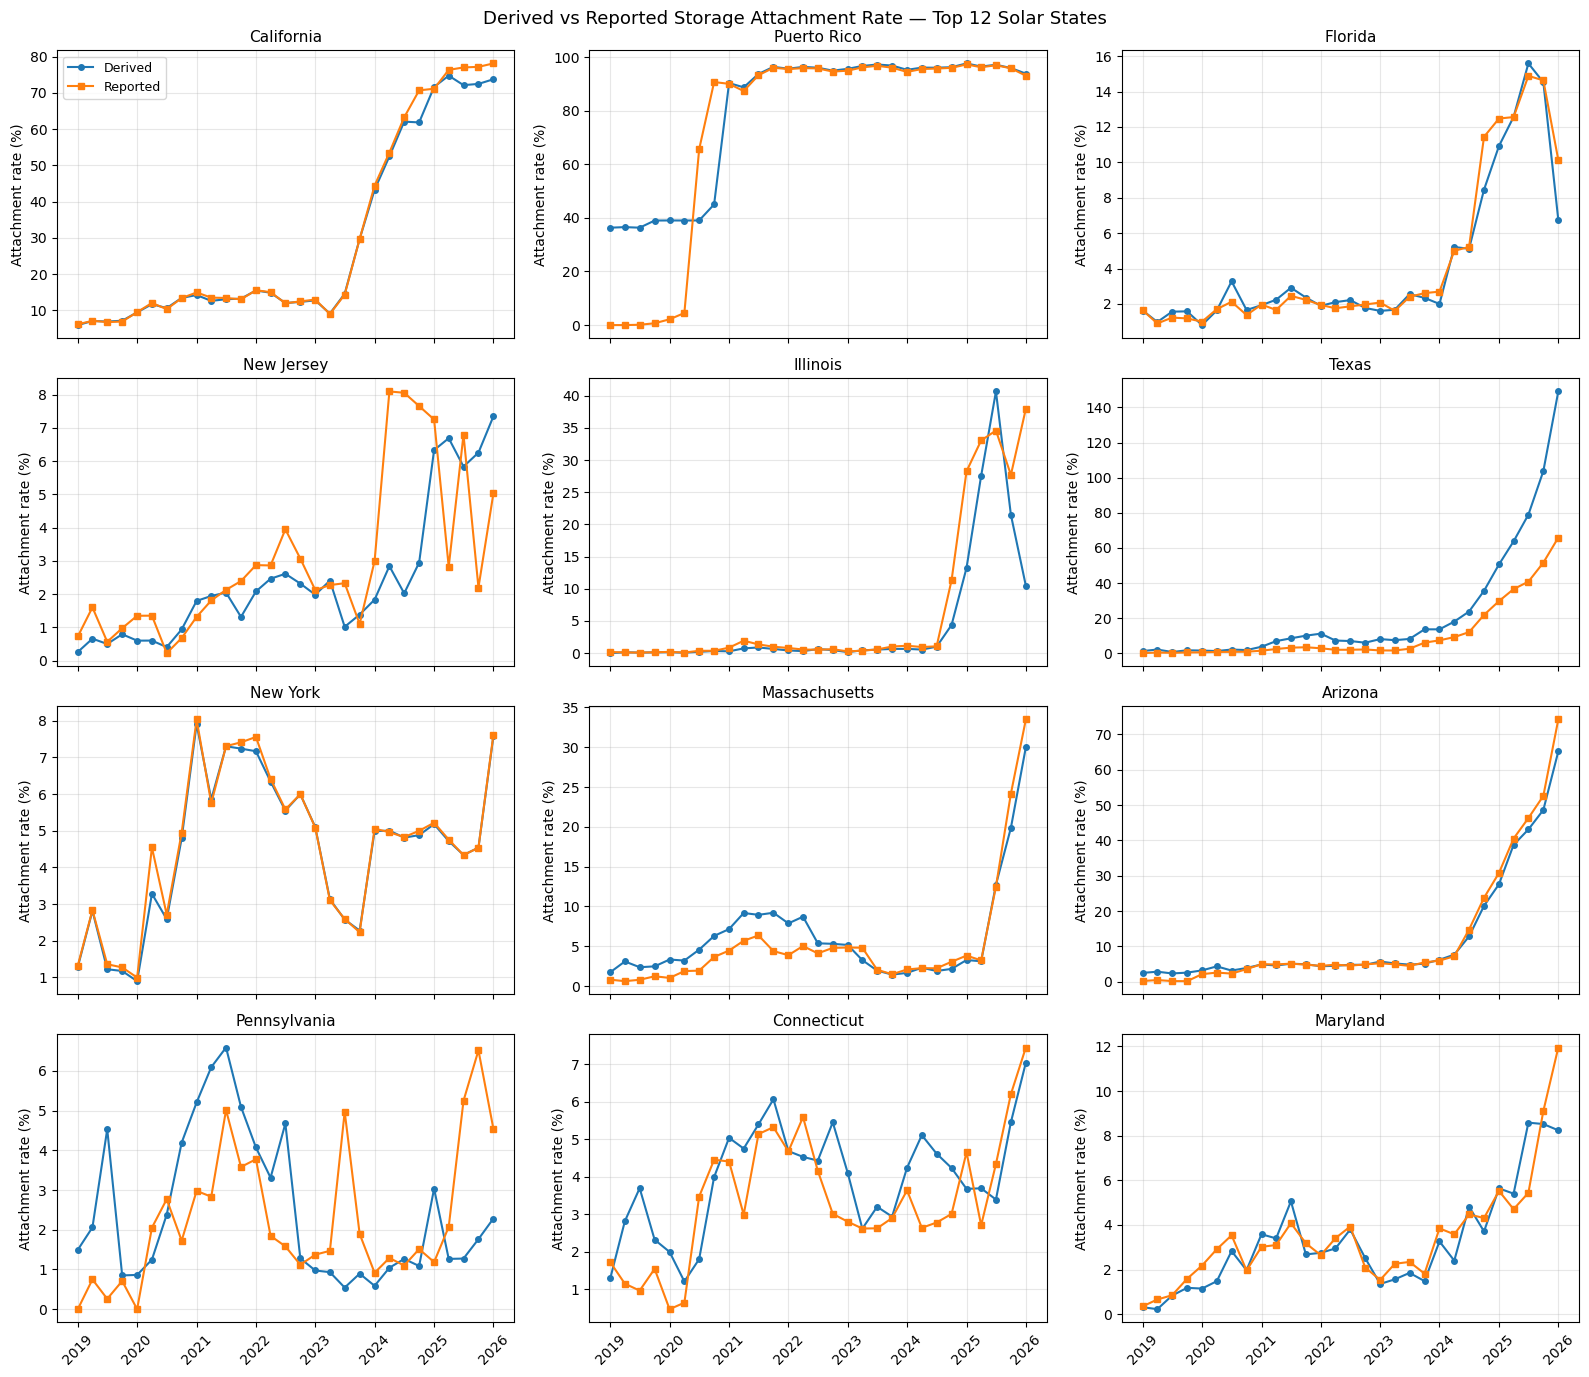

In [64]:
# Derived vs reported attachment rate, by quarter, for the top solar states
# (reuses `top_states` from the plot above -- biggest states by most recent actual solar volume)
n_states = 12
states_to_plot = top_states[:n_states]

fig, axes = plt.subplots(4, 3, figsize=(16, 14), sharex=True)
axes = axes.flatten()

for i, state in enumerate(states_to_plot):
    sub = compare[(compare["State"] == state) & (compare["actual_or_projected"] == "A")].sort_values("period")
    ax = axes[i]
    ax.plot(sub["period"].dt.to_timestamp(), sub["derived_attachment_rate"] * 100, marker="o", markersize=4, label="Derived")
    ax.plot(sub["period"].dt.to_timestamp(), sub["reported_attachment_rate"] * 100, marker="s", markersize=4, label="Reported")
    ax.set_title(state, fontsize=11)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
    if i == 0:
        ax.legend(fontsize=9)

for j in range(len(states_to_plot), len(axes)):
    axes[j].set_visible(False)

for ax in axes[:len(states_to_plot)]:
    ax.set_ylabel("Attachment rate (%)")

plt.suptitle(f"Derived vs Reported Storage Attachment Rate — Top {n_states} Solar States", fontsize=13)
plt.tight_layout()
plt.show()

## 5) Compare to dGen's existing attachment-rate input

`dgen_os/input_data/ohm_attachment_rates.csv` holds quarterly attachment rates (q2_24–q1_25) already wired into the model. Check whether the new export agrees, and how far it now extends.

In [65]:
dgen_path = os.path.join(DGEN_INPUT_DIR, "ohm_attachment_rates.csv")
dgen_rates = pd.read_csv(dgen_path)
print("dGen input columns:", dgen_rates.columns.tolist())
dgen_rates.head()

dGen input columns: ['state_abbr', 'metric', 'q2_24', 'q3_24', 'q4_24', 'q1_25']


,state_abbr,metric,q2_24,q3_24,q4_24,q1_25
0,AR,attachment_rate,0.006228,0.004695,0.003478,0.000000
1,AZ,attachment_rate,0.078428,0.131521,0.225010,0.412927
2,CA,attachment_rate,0.583313,0.683615,0.653536,0.723044
3,CO,attachment_rate,0.068281,0.100784,0.080515,0.097631
4,CT,attachment_rate,0.047892,0.071764,0.051910,0.053785


In [66]:
# dGen input uses full state names in the new export -- need a state_abbr mapping.
# Reuse the repo's states.csv lookup (abbr, full name) if present, else define inline.
states_lookup_path = os.path.abspath(os.path.join(os.path.abspath("."), "..", "..", "..", "states.csv"))
if os.path.exists(states_lookup_path):
    states_lookup = pd.read_csv(states_lookup_path, header=None, names=["state_abbr", "State"])
    attach_q_abbr = attach_q.merge(states_lookup, on="State", how="left")
    unmatched = attach_q_abbr.loc[attach_q_abbr["state_abbr"].isna(), "State"].unique()
    if len(unmatched):
        print("States not in states.csv (dropped from dGen comparison):", unmatched.tolist())
else:
    attach_q_abbr = attach_q.copy()
    attach_q_abbr["state_abbr"] = None
    print("states.csv not found at", states_lookup_path, "- state_abbr left blank")

# dGen input has multiple metrics per state (attachment_rate, install_volume) --
# filter to attachment_rate only, else the merge below silently mixes in volumes.
dgen_attach = dgen_rates[dgen_rates["metric"] == "attachment_rate"].copy()
dgen_qtr_cols = [c for c in dgen_attach.columns if re.match(r"^q[1-4]_\d{2}$", c)]
dgen_long = dgen_attach.melt(id_vars=["state_abbr"], value_vars=dgen_qtr_cols,
                              var_name="qtr_str", value_name="dgen_attachment_rate")
parsed = dgen_long["qtr_str"].str.extract(r"^q([1-4])_(\d{2})$")
dgen_long["period"] = pd.PeriodIndex.from_fields(
    year=2000 + parsed[1].astype(int), quarter=parsed[0].astype(int), freq="Q"
)

merged_compare = pd.merge(
    attach_q_abbr, dgen_long.drop(columns="qtr_str"),
    on=["state_abbr", "period"], how="inner"
)
merged_compare["diff"] = merged_compare["reported_attachment_rate"] - merged_compare["dgen_attachment_rate"]
merged_compare.sort_values(["state_abbr", "period"])

States not in states.csv (dropped from dGen comparison): ['Alaska', 'Hawaii', 'Puerto Rico', 'Washington, DC']


,State,period,reported_attachment_rate,state_abbr,dgen_attachment_rate,diff
4,Arkansas,2024Q2,0.017200,AR,0.006228,0.010972
5,Arkansas,2024Q3,0.015267,AR,0.004695,0.010572
6,Arkansas,2024Q4,0.146200,AR,0.003478,0.142722
7,Arkansas,2025Q1,0.074067,AR,0.000000,0.074067
0,Arizona,2024Q2,0.072133,AZ,0.078428,-0.006295
...,...,...,...,...,...,...
159,Wisconsin,2025Q1,0.013300,WI,0.631034,-0.617734
160,Wyoming,2024Q2,0.025300,WY,0.039125,-0.013825
161,Wyoming,2024Q3,0.000000,WY,0.054545,-0.054545
162,Wyoming,2024Q4,0.057967,WY,0.113143,-0.055176


## 6) Export tidy outputs

In [67]:
out_dir = DATA_DIR
attach_long.to_csv(os.path.join(out_dir, "tidy_monthly_attachment_rate.csv"), index=False)
compare.to_csv(os.path.join(out_dir, "tidy_quarterly_attachment_rate_derived_vs_reported.csv"), index=False)
print("Saved tidy CSVs to", out_dir)

Saved tidy CSVs to /Users/wael/Documents/repos/dgen/data/Ohm Analytics - Battery Attachment Rates


## 7) State summary table: 2025–2026 attachment rate, reported vs. derived

Two-stage aggregation for the **reported** column: monthly reported rate → quarterly (simple mean, `attach_q` above) → 2025Q1–2026Q1 (weighted by that quarter's solar installs).

The **derived** column is `sum(storage_installs) / sum(solar_installs)` over the same quarters — this is inherently solar-installs-weighted since it's a ratio of sums, not an average of ratios.

Only **actual** quarters are used (2025Q1–2026Q1); toggle `INCLUDE_PROJECTED` to fold in projected 2026 quarters too. Sorted by `total_solar_installs`, descending.

⚠️ Some states show large reported-vs-derived gaps (e.g. Alabama: 10.5% reported vs 0.0% derived) even though volumes are real and correctly read — Ohm's "Attachment Rate" file and "Top Storage States" file appear to use different underlying populations/definitions for some states. Raw install totals are included so you can judge how much to trust each state's ratio (small volumes → noisier ratios).

In [68]:
INCLUDE_PROJECTED = False  # set True to also fold in projected 2026 quarters

mask_years = counts["period"].dt.year.isin([2025, 2026])
mask_ap = counts["actual_or_projected"].isin(["A", "P"] if INCLUDE_PROJECTED else ["A"])
window = counts[mask_years & mask_ap & (counts["State"] != "National")].copy()
window = window.merge(attach_q, on=["State", "period"], how="left")

def agg_group(g):
    solar_sum = g["solar_installs"].sum()
    storage_sum = g["storage_installs"].sum()
    weights = g["solar_installs"].clip(lower=0)
    reported_wavg = np.average(g["reported_attachment_rate"].fillna(0), weights=weights) if weights.sum() > 0 else np.nan
    derived = storage_sum / solar_sum if solar_sum > 0 else np.nan
    return pd.Series({
        "reported_wavg_attachment_rate": reported_wavg,
        "derived_attachment_rate": derived,
        "total_solar_installs": solar_sum,
        "total_storage_installs": storage_sum,
        "n_quarters": g["period"].nunique(),
    })

state_summary = (
    window.groupby("State").apply(agg_group, include_groups=False)
    .reset_index().sort_values("total_solar_installs", ascending=False).reset_index(drop=True)
)

period_label = "2025-2026" + (" (incl. projected)" if INCLUDE_PROJECTED else " (actual only)")
display_tbl = state_summary.copy()
display_tbl[f"{period_label} Attachment Rate (Reported, solar-weighted)"] = (display_tbl["reported_wavg_attachment_rate"] * 100).round(1)
display_tbl[f"{period_label} Attachment Rate (Derived: storage/solar)"] = (display_tbl["derived_attachment_rate"] * 100).round(1)

cols = ["State",
        f"{period_label} Attachment Rate (Reported, solar-weighted)",
        f"{period_label} Attachment Rate (Derived: storage/solar)",
        "total_solar_installs", "total_storage_installs", "n_quarters"]
display_tbl = display_tbl[cols]
display_tbl

,State,"2025-2026 (actual only) Attachment Rate (Reported, solar-weighted)",2025-2026 (actual only) Attachment Rate (Derived: storage/solar),total_solar_installs,total_storage_installs,n_quarters
0,California,76.1,73.0,237123.0,173059.0,5.0
1,Puerto Rico,96.0,96.3,58563.0,56411.0,5.0
2,Florida,13.0,12.1,45471.0,5493.0,5.0
3,Texas,43.9,86.4,35359.0,30547.0,5.0
4,New York,5.2,5.1,31177.0,1605.0,5.0
5,Massachusetts,14.7,13.1,28857.0,3771.0,5.0
6,New Jersey,4.7,6.5,25946.0,1695.0,5.0
7,Illinois,32.4,20.9,23293.0,4876.0,5.0
8,Arizona,48.5,44.4,21885.0,9709.0,5.0
9,Connecticut,5.1,4.7,18573.0,865.0,5.0


In [69]:
display_tbl.to_csv(os.path.join(out_dir, "state_summary_2025_2026_attachment_rate.csv"), index=False)
print("Saved to", os.path.join(out_dir, "state_summary_2025_2026_attachment_rate.csv"))

Saved to /Users/wael/Documents/repos/dgen/data/Ohm Analytics - Battery Attachment Rates/state_summary_2025_2026_attachment_rate.csv
